In [1]:
# Import required Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
# Load Africa population dataset directly from Worldometer website
# A browser header is included to prevent HTTP 403 Forbidden error

url = "https://www.worldometers.info/population/countries-in-africa-by-population/"

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

data = pd.read_html(response.text)[0]

# Display first five rows to confirm successful data loading

data.head()

/tmp/ipykernel_16731/1849007519.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_html(response.text)[0]


,#,Country (or dependency),Population (2026),Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,Nigeria,242431832,2.06%,4904050,266,910770,"â2,810",4.2,18,56%,2.92%
1,2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
2,3,Egypt,120101175,1.47%,1735180,121,995450,"â52,287",2.7,25,41%,1.45%
3,4,DR Congo,116452162,3.21%,3619689,51,2267050,"â28,843",5.8,16,45%,1.40%
4,5,Tanzania,72563780,2.86%,2017915,82,885800,"â25,275",4.4,18,41%,0.87%


In [3]:
# Rename dataset columns for clarity and consistency

data.columns = [
    "Rank",
    "Country",
    "Population",
    "Yearly_Change",
    "NetChange",
    "PopDensity",
    "LandArea",
    "Migrants",
    "FertRate",
    "MedAge",
    "UrbanPopulation",
    "WorldShare"
]

In [4]:
# Remove percentage symbols to allow numeric conversion

data["Yearly_Change"] = data["Yearly_Change"].str.replace('%','')
data["UrbanPopulation"] = data["UrbanPopulation"].str.replace('%','')
data["WorldShare"] = data["WorldShare"].str.replace('%','')

In [5]:
# Convert selected columns into numeric format for correlation analysis

numeric_columns = [
    "Population",
    "Yearly_Change",
    "NetChange",
    "PopDensity",
    "LandArea",
    "Migrants",
    "FertRate",
    "MedAge",
    "UrbanPopulation",
    "WorldShare"
]

data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [6]:
# Remove rows containing missing values to produce a clean dataset

data = data.dropna()

# Confirm dataset structure after cleaning

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 56
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             15 non-null     int64  
 1   Country          15 non-null     object 
 2   Population       15 non-null     int64  
 3   Yearly_Change    15 non-null     float64
 4   NetChange        15 non-null     float64
 5   PopDensity       15 non-null     int64  
 6   LandArea         15 non-null     int64  
 7   Migrants         15 non-null     float64
 8   FertRate         15 non-null     float64
 9   MedAge           15 non-null     int64  
 10  UrbanPopulation  15 non-null     float64
 11  WorldShare       15 non-null     float64
dtypes: float64(6), int64(5), object(1)
memory usage: 1.5+ KB


In [7]:
# Select variables for heat map

selected_data = data[[
    "Population",
    "NetChange",
    "PopDensity",
    "LandArea",
    "FertRate",
    "MedAge"
]]

In [8]:
# Compute correlation values between selected dataset variables

correlation_matrix = selected_data.corr()

# Display correlation matrix values

correlation_matrix

,Population,NetChange,PopDensity,LandArea,FertRate,MedAge
Population,1.000000,0.959723,0.159327,0.435744,0.176804,-0.276623
NetChange,0.959723,1.000000,0.168565,0.405481,0.315821,-0.391314
PopDensity,0.159327,0.168565,1.000000,-0.418503,-0.137879,0.161502
LandArea,0.435744,0.405481,-0.418503,1.000000,0.007532,-0.084551
FertRate,0.176804,0.315821,-0.137879,0.007532,1.000000,-0.857922
MedAge,-0.276623,-0.391314,0.161502,-0.084551,-0.857922,1.000000


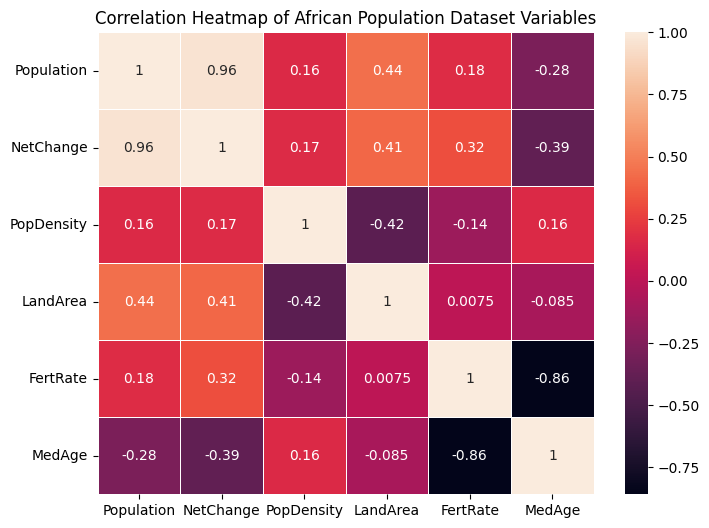

In [9]:
# Visualize correlations using a heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="rocket",
    linewidths=0.5
)

plt.title("Correlation Heatmap of African Population Dataset Variables")

plt.show()

In [10]:
# Save cleaned dataset as CSV file for submission

data.to_csv("clean_africa_population.csv", index=False)

In [11]:
# Download cleaned dataset to local computer

from google.colab import files
files.download("clean_africa_population.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Interpretation of dataset relationships observed from the heatmap

print("Population shows strong positive correlation with NetChange.")
print("Fertility Rate shows strong negative correlation with Median Age.")
print("Land Area shows moderate correlation with Population.")
print("Population Density shows weaker correlations with most variables.")

Population shows strong positive correlation with NetChange.
Fertility Rate shows strong negative correlation with Median Age.
Land Area shows moderate correlation with Population.
Population Density shows weaker correlations with most variables.
